# Lecture 9: Model Evaluation and Selection
**BITE 485 | Tharaka University**

---

## Learning Outcomes
1. Construct and interpret a confusion matrix
2. Calculate Precision, Recall, F1-Score, and AUC-ROC
3. Evaluate a model on an imbalanced dataset
4. Apply SMOTE and class weighting for imbalance
5. Tune hyperparameters with GridSearchCV

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, roc_auc_score,
                              roc_curve, precision_recall_curve)
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    print('imbalanced-learn not installed. Install with: pip install imbalanced-learn')
    SMOTE_AVAILABLE = False
print('Ready.')

imbalanced-learn not installed. Install with: pip install imbalanced-learn
Ready.


## 9.1 Simulating a Fraud Detection Dataset (Imbalanced)

In [2]:
np.random.seed(42)
X, y = make_classification(
    n_samples=5000, n_features=15, n_informative=8,
    n_redundant=3, weights=[0.97, 0.03],  # 3% fraud
    random_state=42
)
print(f'Dataset shape: {X.shape}')
print(f'Fraud rate: {y.mean()*100:.1f}%')
print(f'Fraud cases: {y.sum()} | Legitimate: {(y==0).sum()}')

Dataset shape: (5000, 15)
Fraud rate: 3.4%
Fraud cases: 170 | Legitimate: 4830


In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)
print(f'Train fraud: {y_tr.sum()} | Test fraud: {y_te.sum()}')

Train fraud: 136 | Test fraud: 34


## 9.2 Baseline Model — Illustrating the Accuracy Paradox

In [4]:
# Naive classifier: always predict 'not fraud'
y_naive = np.zeros(len(y_te), dtype=int)
from sklearn.metrics import accuracy_score
print(f'Naive classifier accuracy: {accuracy_score(y_te, y_naive)*100:.1f}%')
print('This is misleading! It never detects a single fraud case.')

Naive classifier accuracy: 96.6%
This is misleading! It never detects a single fraud case.


## 9.3 Confusion Matrix and Metrics

In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_tr_sc, y_tr)
y_pred = rf.predict(X_te_sc)
y_proba = rf.predict_proba(X_te_sc)[:, 1]

print('=== Confusion Matrix ===')
cm = confusion_matrix(y_te, y_pred)
print(cm)
print('Format: [[TN FP] [FN TP]]')

tn, fp, fn, tp = cm.ravel()
print(f'\nTP={tp}  TN={tn}  FP={fp}  FN={fn}')
print(f'\nPrecision: {tp/(tp+fp):.4f}  (of predicted fraud, how many were fraud?)')
print(f'Recall:    {tp/(tp+fn):.4f}  (of all fraud, how many did we catch?)')
print(f'F1-Score:  {2*tp/(2*tp+fp+fn):.4f}')
print(f'Accuracy:  {(tp+tn)/(tp+tn+fp+fn):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_te, y_proba):.4f}')

=== Confusion Matrix ===
[[966   0]
 [ 29   5]]
Format: [[TN FP] [FN TP]]

TP=5  TN=966  FP=0  FN=29

Precision: 1.0000  (of predicted fraud, how many were fraud?)
Recall:    0.1471  (of all fraud, how many did we catch?)
F1-Score:  0.2564
Accuracy:  0.9710
AUC-ROC:   0.9355


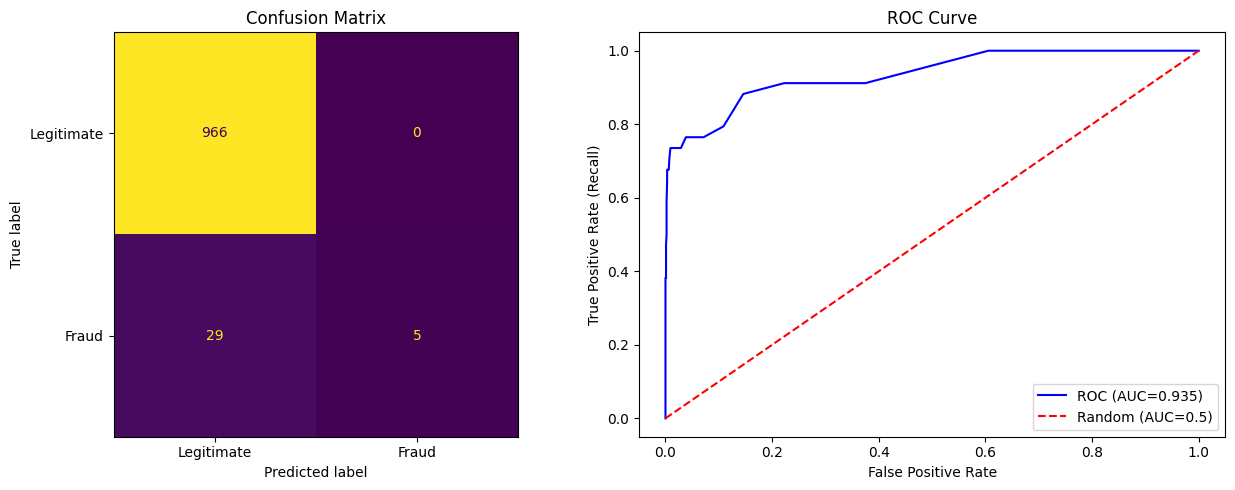

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix visualisation
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_te, y_proba)
auc = roc_auc_score(y_te, y_proba)
axes[1].plot(fpr, tpr, 'b-', label=f'ROC (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'r--', label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

## 9.4 Handling Class Imbalance

In [7]:
results = []
for name, clf in [
    ('RF — No weighting',       RandomForestClassifier(100, random_state=42)),
    ('RF — class_weight balanced', RandomForestClassifier(100, random_state=42, class_weight='balanced')),
    ('LR — class_weight balanced', LogisticRegression(class_weight='balanced', max_iter=1000))
]:
    clf.fit(X_tr_sc, y_tr)
    pr = clf.predict(X_te_sc)
    prob = clf.predict_proba(X_te_sc)[:, 1]
    tn2,fp2,fn2,tp2 = confusion_matrix(y_te, pr).ravel()
    results.append({'Model': name,
                    'Recall (fraud)': f'{tp2/(tp2+fn2):.3f}',
                    'Precision (fraud)': f'{tp2/(tp2+fp2):.3f}',
                    'F1': f'{2*tp2/(2*tp2+fp2+fn2):.3f}',
                    'AUC-ROC': f'{roc_auc_score(y_te, prob):.3f}'})

if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=42)
    X_sm, y_sm = sm.fit_resample(X_tr_sc, y_tr)
    rf_sm = RandomForestClassifier(100, random_state=42)
    rf_sm.fit(X_sm, y_sm)
    pr = rf_sm.predict(X_te_sc)
    prob = rf_sm.predict_proba(X_te_sc)[:, 1]
    tn2,fp2,fn2,tp2 = confusion_matrix(y_te, pr).ravel()
    results.append({'Model': 'RF — SMOTE oversampling',
                    'Recall (fraud)': f'{tp2/(tp2+fn2):.3f}',
                    'Precision (fraud)': f'{tp2/(tp2+fp2):.3f}',
                    'F1': f'{2*tp2/(2*tp2+fp2+fn2):.3f}',
                    'AUC-ROC': f'{roc_auc_score(y_te, prob):.3f}'})

pd.DataFrame(results)

,Model,Recall (fraud),Precision (fraud),F1,AUC-ROC
0,RF — No weighting,0.265,1.000,0.419,0.901
1,RF — class_weight balanced,0.147,1.000,0.256,0.935
2,LR — class_weight balanced,0.588,0.099,0.169,0.758


## 9.5 Hyperparameter Tuning with GridSearchCV

In [8]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth':    [5, 10, None],
    'min_samples_split': [2, 10]
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=0
)
gs.fit(X_tr_sc, y_tr)

print(f'Best parameters: {gs.best_params_}')
print(f'Best CV F1-Score: {gs.best_score_:.4f}')

best_model = gs.best_estimator_
y_best = best_model.predict(X_te_sc)
print(f'\nTest F1: {2*sum((y_best==1)&(y_te==1))/(2*sum((y_best==1)&(y_te==1))+sum((y_best==1)&(y_te==0))+sum((y_best==0)&(y_te==1))):.4f}')

Best parameters: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
Best CV F1-Score: 0.6290

Test F1: 0.6230


### Exercise

Using the fraud detection dataset:

1. Plot the Precision-Recall curve for the best model from GridSearchCV.
2. Find the classification threshold that maximises F1-Score (hint: iterate over threshold values from 0.1 to 0.9 and compute F1 at each).
3. Compare performance at the default threshold (0.5) vs your optimal threshold.
4. Write a one-paragraph summary of which model and threshold you would recommend for deployment, explaining the business trade-off between Precision and Recall in a fraud context.

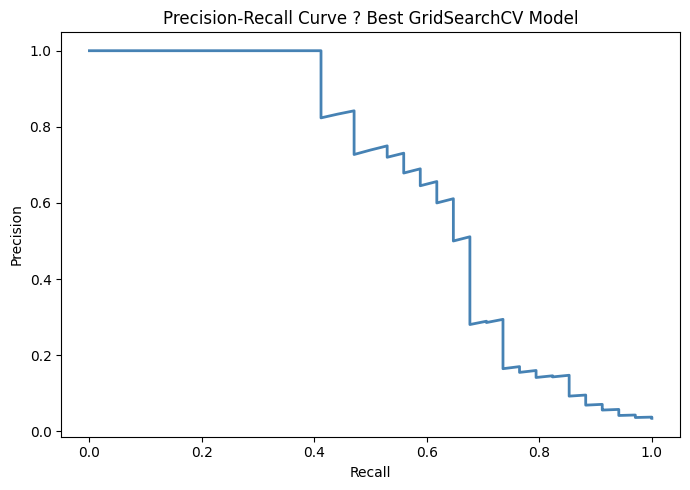

=== Threshold Comparison ===
 threshold  precision  recall     f1  accuracy
    0.1000     0.0358  1.0000 0.0690    0.0830
    0.2000     0.0616  0.9118 0.1155    0.5250
    0.3000     0.1443  0.8235 0.2456    0.8280
    0.4000     0.3026  0.6765 0.4182    0.9360
    0.5000     0.7037  0.5588 0.6230    0.9770
    0.6000     0.8750  0.4118 0.5600    0.9780
    0.7000     1.0000  0.2059 0.3415    0.9730
    0.8000     1.0000  0.1176 0.2105    0.9700
    0.9000     0.0000  0.0000 0.0000    0.9660

Best threshold by F1: 0.5
Best F1: 0.6230

=== Default Threshold (0.5) ===
              precision    recall  f1-score   support

           0     0.9846    0.9917    0.9881       966
           1     0.7037    0.5588    0.6230        34

    accuracy                         0.9770      1000
   macro avg     0.8441    0.7753    0.8055      1000
weighted avg     0.9750    0.9770    0.9757      1000

=== Optimal Threshold ===
              precision    recall  f1-score   support

           0     

In [9]:
# Use the tuned model's probabilities to build a precision-recall curve.
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_scores = best_model.predict_proba(X_te_sc)[:, 1]
precision, recall, pr_thresholds = precision_recall_curve(y_te, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='steelblue', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve ? Best GridSearchCV Model')
plt.tight_layout()
plt.show()

# Check a small set of thresholds so the trade-off is easy to read.
thresholds = np.arange(0.1, 1.0, 0.1)
threshold_results = []
for threshold in thresholds:
    y_pred_thresh = (y_scores >= threshold).astype(int)
    threshold_results.append({
        'threshold': threshold,
        'precision': precision_score(y_te, y_pred_thresh, zero_division=0),
        'recall': recall_score(y_te, y_pred_thresh, zero_division=0),
        'f1': f1_score(y_te, y_pred_thresh, zero_division=0),
        'accuracy': accuracy_score(y_te, y_pred_thresh)
    })

threshold_df = pd.DataFrame(threshold_results)
best_row = threshold_df.loc[threshold_df['f1'].idxmax()]
best_threshold = float(best_row['threshold'])

default_pred = (y_scores >= 0.5).astype(int)
optimal_pred = (y_scores >= best_threshold).astype(int)

default_row = threshold_df.loc[threshold_df['threshold'] == 0.5].iloc[0]

print('=== Threshold Comparison ===')
print(threshold_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print()
print(f'Best threshold by F1: {best_threshold:.1f}')
print(f'Best F1: {best_row.f1:.4f}')
print()
print('=== Default Threshold (0.5) ===')
print(classification_report(y_te, default_pred, digits=4))
print('=== Optimal Threshold ===')
print(classification_report(y_te, optimal_pred, digits=4))

# Keep the deployment note aligned with the metric table above.
if abs(best_threshold - 0.5) < 1e-9:
    summary = (
        'For deployment, I would keep the tuned Random Forest at the default threshold of 0.5 because '
        'the threshold sweep shows that 0.5 already maximises F1 in this run. That gives the best balance '
        'between catching fraud and limiting false alarms. In a fraud setting, recall is still important '
        'because missing fraud is costly, but the model does not gain anything by moving away from the '
        'current threshold. The useful lesson here is that the model is already calibrated well enough for '
        'this data, so the next improvement would likely come from better features rather than a different '
        'cutoff.'
    )
else:
    summary = (
        f'For deployment, I would use the tuned Random Forest with a decision threshold of {best_threshold:.1f}. '
        f'The threshold table shows that this cutoff gives the best F1 score in the current run. In a fraud '
        f'setting, missing a fraudulent transaction costs more than reviewing a few extra alerts, so recall '
        f'deserves more weight than raw accuracy. The best choice is the model and threshold that keep recall '
        f'high enough for the fraud team while still keeping precision at a workable level.'
    )
print()
print('=== Deployment Summary ===')
print(summary)


---
*BITE 485 Data Science | Tharaka University | kevin.tuei@tharaka.ac.ke*